# Notebook 13 — Detección de singularidades territoriales mediante Isolation Forest

## Finalidad

En este notebook aplicamos Isolation Forest para identificar territorios con perfiles multivariantes especialmente singulares.

Partimos de la matriz estandarizada generada en el Notebook 12: 22 territorios NUTS 2 y 21 variables analíticas. El archivo contiene además cuatro campos de identificación, por lo que su dimensión es 22 × 25.

No volvemos a seleccionar, transformar ni estandarizar variables. Andorra se mantiene como unidad territorial complementaria y no participa en el ajuste del modelo.

Los objetivos son:

1. ordenar los territorios según su grado de singularidad;
2. comprobar la estabilidad del resultado con distintas semillas;
3. revisar su sensibilidad al parámetro `contamination`;
4. caracterizar los territorios detectados sin eliminarlos automáticamente.

## Criterios metodológicos

Trabajamos con las 21 variables seleccionadas en el Notebook 12, distribuidas entre nueve familias. La familia Eléctrica está representada por los indicadores de densidad de líneas de alta tensión y densidad de subestaciones.

En el Notebook 12 se aplicó `log1p` a nueve variables y conservamos las otras doce sin transformar antes de estandarizar el conjunto mediante `StandardScaler`.

Isolation Forest usa esta matriz estandarizada. Los análisis posteriores comenzarán de las salidas validadas de esta fase y aplicarán, cuando corresponda, sus propios diagnósticos metodológicos.

Estudiamos las semillas y los valores de `contamination` por separado para distinguir la estabilidad frente a la aleatoriedad del modelo de la sensibilidad al umbral usado.

`contamination` es un parámetro operativo del modelo, no el porcentaje real de territorios anómalos. No eliminamos territorios de forma automática por aparecer como singular.


In [1]:
# Importaciones y rutas
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42
N_ESTIMATORS = 500
CONTAMINATION_BASE = 0.10

INPUT_DIR = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/salidas_notebook_13")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Localizamos el paquete final del Notebook 12.
candidatas_00a = [
    ruta
    for ruta in INPUT_DIR.rglob("matriz_estandarizada_22x25.csv")
    if (
        (ruta.parent / "seleccion_final_21_variables.csv").exists()
        and (ruta.parent / "configuracion_preparacion.json").exists()
    )
]

if len(candidatas_00a) != 1:
    raise FileNotFoundError(
        "No se ha localizado una única salida válida del Notebook 12."
    )

MATRIZ_PATH = candidatas_00a[0]
INPUT_NB12 = MATRIZ_PATH.parent
SELECCION_PATH = INPUT_NB12 / "seleccion_final_21_variables.csv"
CONFIG_PATH = INPUT_NB12 / "configuracion_preparacion.json"

print("Carpeta Notebook 12:", INPUT_NB12)
print("Entradas localizadas: 3")


Carpeta Notebook 12: /kaggle/input/datasets/aemjeloy/salidas-ntb12
Entradas localizadas: 3


## Carga y comprobación de los datos

Cargamos la matriz estandarizada, la selección de variables y la configuración generadas en el Notebook 12.

Antes de aplicar Isolation Forest comprobamos que la matriz contiene 22 territorios, cuatro campos de identificación y 21 variables analíticas. También revisamos que no existan territorios duplicados, valores ausentes, infinitos ni variables constantes.

Finalmente, verificamos que las 21 variables coincidan con la selección registrada en el Notebook 12.


In [2]:
# Carga y comprobaciones
import json

df = pd.read_csv(MATRIZ_PATH)
seleccion = pd.read_csv(SELECCION_PATH)
configuracion = json.loads(
    CONFIG_PATH.read_text(encoding="utf-8")
)
id_cols = [
    "codigo_geo",
    "nombre_territorio",
    "pais",
    "ambito_modelo",
]
variables = seleccion["variable"].tolist()

correcto_01a = (
    df.shape == (22, 25)
    and len(variables) == 21
    and set(df.columns) == set(id_cols + variables)
    and df["codigo_geo"].is_unique
    and not (df["codigo_geo"] == "AD").any()
    and not df[variables].isna().any().any()
    and np.isfinite(df[variables].to_numpy()).all()
    and df[variables].nunique().gt(1).all()
    and configuracion["variables_finales"] == 21
)
if not correcto_01a:
    raise ValueError("La matriz del Notebook 12 necesita revisión.")

print(
    "Matriz:", df.shape,
    "| Variables:", len(variables),
    "| Nulos:", int(df[variables].isna().sum().sum()),
)


Matriz: (22, 25) | Variables: 21 | Nulos: 0


## Matriz de entrada para Isolation Forest

Separamos las 21 variables analíticas de los campos de identificación territorial.

Utilizamos directamente la matriz estandarizada del Notebook 12. En este notebook no aplicamos nuevas transformaciones, filtros de variables ni otro escalado.

La matriz `X`, formada por 22 territorios y 21 variables, será la entrada de Isolation Forest.


In [3]:
# Matriz para Isolation Forest
X = df[variables].copy()
territorios = df[
    ["codigo_geo", "nombre_territorio", "pais"]
].copy()

if X.shape != (22, 21):
    raise ValueError("La matriz de Isolation Forest necesita revisión.")

print("Matriz X:", X.shape)


Matriz X: (22, 21)


## Modelo de referencia

Aplicamos una primera ejecución de Isolation Forest con 500 árboles, `random_state=42` y `contamination=0.10`.

Este valor de `contamination` se utiliza como umbral operativo y no significa que el 10 % de los territorios sean anomalías reales.

El modelo permitirá ordenar los 22 territorios según su grado de singularidad. Ningún territorio se eliminará como resultado de esta clasificación.


In [4]:
# Modelo de referencia
modelo_if = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION_BASE,
    random_state=RANDOM_STATE,
)
prediccion = modelo_if.fit_predict(X)
resultados_if = territorios.copy()
resultados_if["score_anomalia"] = (
    -modelo_if.decision_function(X)
)
resultados_if["singular"] = prediccion == -1
resultados_if = resultados_if.sort_values(
    "score_anomalia",
    ascending=False,
).reset_index(drop=True)

print(
    "Singulares:",
    int(resultados_if["singular"].sum()),
)

display(resultados_if.head(10))

Singulares: 3


,codigo_geo,nombre_territorio,pais,score_anomalia,singular
0,PT1A,Grande Lisboa,Portugal,0.040798,True
1,PT1B,Península de Setúbal,Portugal,0.001776,True
2,ES30,Comunidad de Madrid,España,0.000113,True
3,PT15,Algarve,Portugal,-0.001020,False
4,PT1C,Alentejo,Portugal,-0.003162,False
5,ES43,Extremadura,España,-0.003279,False
6,ES61,Andalucía,España,-0.011019,False
7,ES42,Castilla-La Mancha,España,-0.025698,False
8,PT11,Norte,Portugal,-0.026472,False
9,ES62,Región de Murcia,España,-0.026947,False


## Estabilidad entre semillas

Isolation Forest utiliza particiones aleatorias, por lo que repetimos el modelo con cinco semillas.

Mantenemos fijos los 500 árboles y `contamination=0.10`. Para cada territorio contamos cuántas veces aparece como singular.

Esta prueba permite comprobar si la clasificación es estable frente a la aleatoriedad del modelo.


In [5]:
# Estabilidad entre semillas
semillas = [13, 21, 42, 73, 101]
estabilidad = territorios.copy()
estabilidad["veces_singular"] = 0

for semilla in semillas:
    modelo = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination=CONTAMINATION_BASE,
        random_state=semilla,
    )
    prediccion = modelo.fit_predict(X)
    estabilidad["veces_singular"] += (
        prediccion == -1
    ).astype(int)
estabilidad["frecuencia"] = (
    estabilidad["veces_singular"] / len(semillas)
)
estabilidad = estabilidad.sort_values(
    "veces_singular",
    ascending=False,
).reset_index(drop=True)

print("Semillas evaluadas:", len(semillas))

display(estabilidad.head(10))

Semillas evaluadas: 5


,codigo_geo,nombre_territorio,pais,veces_singular,frecuencia
0,PT1A,Grande Lisboa,Portugal,5,1.0
1,PT1B,Península de Setúbal,Portugal,4,0.8
2,PT15,Algarve,Portugal,3,0.6
3,ES30,Comunidad de Madrid,España,3,0.6
4,ES11,Galicia,España,0,0.0
5,ES12,Principado de Asturias,España,0,0.0
6,ES23,La Rioja,España,0,0.0
7,ES22,Comunidad Foral de Navarra,España,0,0.0
8,ES21,País Vasco,España,0,0.0
9,ES13,Cantabria,España,0,0.0


## Sensibilidad a `contamination`

Comprobamos cómo cambia la clasificación al modificar `contamination`.

Mantenemos fijos la semilla 42 y los 500 árboles, y evaluamos los valores `0.05`, `0.10` y `0.15`.

Esta prueba se analiza por separado de las semillas para distinguir la sensibilidad al umbral de la aleatoriedad del modelo.


In [6]:
# Sensibilidad a contamination
contaminaciones = [0.05, 0.10, 0.15]
sensibilidad = territorios.copy()

for valor in contaminaciones:
    modelo = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination=valor,
        random_state=RANDOM_STATE,
    )
    prediccion = modelo.fit_predict(X)
    columna = f"cont_{int(valor * 100):02d}"
    sensibilidad[columna] = prediccion == -1

print("Umbrales evaluados:", len(contaminaciones))

display(sensibilidad)

Umbrales evaluados: 3


,codigo_geo,nombre_territorio,pais,cont_05,cont_10,cont_15
0,ES11,Galicia,España,False,False,False
1,ES12,Principado de Asturias,España,False,False,False
2,ES13,Cantabria,España,False,False,False
3,ES21,País Vasco,España,False,False,False
4,ES22,Comunidad Foral de Navarra,España,False,False,False
5,ES23,La Rioja,España,False,False,False
6,ES24,Aragón,España,False,False,False
7,ES30,Comunidad de Madrid,España,False,True,True
8,ES41,Castilla y León,España,False,False,False
9,ES42,Castilla-La Mancha,España,False,False,False


## Síntesis de estabilidad y sensibilidad

Grande Lisboa presenta la singularidad más consistente: aparece con las cinco semillas y con los tres valores de `contamination`.

Península de Setúbal aparece con cuatro de las cinco semillas y con los tres umbrales. Su resultado es estable, aunque muestra una ligera sensibilidad a la aleatoriedad.

Comunidad de Madrid aparece con tres semillas y con `contamination=0.10` y `0.15`, mientras que Algarve aparece con tres semillas y únicamente con `0.15`.

Por tanto, Lisboa y Setúbal forman el núcleo más robusto. Madrid presenta una singularidad intermedia y Algarve depende más del umbral utilizado.

Estas clasificaciones se utilizan para interpretar los perfiles territoriales y no para eliminar observaciones.


In [7]:
# Resumen de robustez
resumen_robustez = sensibilidad.merge(
    estabilidad[
        ["codigo_geo", "veces_singular", "frecuencia"]
    ],
    on="codigo_geo",
)
resumen_robustez["n_umbrales"] = resumen_robustez[
    ["cont_05", "cont_10", "cont_15"]
].sum(axis=1)
resumen_robustez = resumen_robustez.sort_values(
    ["n_umbrales", "veces_singular"],
    ascending=False,
).reset_index(drop=True)

print("Territorios evaluados:", len(resumen_robustez))

display(
    resumen_robustez[
        [
            "codigo_geo",
            "nombre_territorio",
            "veces_singular",
            "frecuencia",
            "cont_05",
            "cont_10",
            "cont_15",
            "n_umbrales",
        ]
    ].head(10)
)

Territorios evaluados: 22


,codigo_geo,nombre_territorio,veces_singular,frecuencia,cont_05,cont_10,cont_15,n_umbrales
0,PT1A,Grande Lisboa,5,1.0,True,True,True,3
1,PT1B,Península de Setúbal,4,0.8,True,True,True,3
2,ES30,Comunidad de Madrid,3,0.6,False,True,True,2
3,PT15,Algarve,3,0.6,False,False,True,1
4,ES11,Galicia,0,0.0,False,False,False,0
5,ES12,Principado de Asturias,0,0.0,False,False,False,0
6,ES13,Cantabria,0,0.0,False,False,False,0
7,ES21,País Vasco,0,0.0,False,False,False,0
8,ES22,Comunidad Foral de Navarra,0,0.0,False,False,False,0
9,ES23,La Rioja,0,0.0,False,False,False,0


## Interpretación de los territorios singulares

Analizamos los perfiles de Grande Lisboa, Península de Setúbal, Comunidad de Madrid y Algarve, ya que son los únicos territorios detectados en alguna prueba de estabilidad o sensibilidad.

Como la matriz está estandarizada, los valores positivos indican que el territorio se sitúa por encima de la media y los negativos, por debajo.

Para cada territorio revisamos las seis variables con mayor desviación absoluta. Esta comparación sirve para caracterizar los perfiles detectados, pero no representa una importancia interna de variables de Isolation Forest.


In [8]:
# Variables extremas por territorio
territorios_clave = resumen_robustez.loc[
    (resumen_robustez["n_umbrales"] > 0)
    | (resumen_robustez["veces_singular"] > 0),
    "nombre_territorio",
].tolist()

for territorio in territorios_clave:
    fila = df.loc[
        df["nombre_territorio"] == territorio,
        variables,
    ].iloc[0]

    extremos = fila.loc[
        fila.abs().nlargest(6).index
    ]

    print(f"\n{territorio}")
    print(extremos.round(3))

print("\nTerritorios caracterizados:", len(territorios_clave))



Grande Lisboa
corine_compat_media_0_3                         2.671
logistica_road_alta_capacidad_km_por_1000km2    2.517
digital_torres_mastiles_1000km2                 2.408
densidad_poblacion                              2.350
digital_exchanges_centrales_telecom_1000km2     2.207
electrica_densidad_subestaciones_1000km2        2.074
Name: 18, dtype: float64

Península de Setúbal
digital_exchanges_centrales_telecom_1000km2     2.893
digital_torres_mastiles_1000km2                 1.987
electrica_densidad_alta_tension_km_1000km2      1.792
punto_rocio_medio_c                             1.731
electrica_densidad_subestaciones_1000km2        1.721
logistica_road_alta_capacidad_km_por_1000km2    1.533
Name: 19, dtype: float64

Comunidad de Madrid
densidad_poblacion                              1.819
poblacion_edad_laboral                          1.599
logistica_road_alta_capacidad_km_por_1000km2    1.566
punto_rocio_medio_c                            -1.492
nivel_formativo_terciario   

### Interpretación de los perfiles

**Grande Lisboa** presenta un perfil urbano, logístico, digital y eléctrico. Destacan la compatibilidad CORINE, la densidad de vías de alta capacidad, la infraestructura digital, la densidad de población y las subestaciones.

**Península de Setúbal** destaca principalmente por la infraestructura digital y eléctrica. También presenta valores elevados en vías de alta capacidad y punto de rocío.

**Comunidad de Madrid** muestra un perfil metropolitano, con valores altos en densidad de población, población en edad laboral, accesibilidad viaria, formación terciaria y centros de datos. Su punto de rocío se encuentra por debajo de la media.

**Algarve** presenta un perfil climático, hídrico y fotovoltaico. Destaca por el estrés hídrico, la producción solar y la temperatura, mientras que muestra valores bajos en centros de datos y formación terciaria.

Estas variables permiten caracterizar los territorios, pero no representan una explicación causal ni una importancia interna calculada por Isolation Forest.


## Visualización de los perfiles territoriales

Representamos las seis variables que más diferencian a cada territorio respecto a la media de las 22 regiones comparables.

Los valores del gráfico están estandarizados:

- **0** representa la media de las 22 regiones;
- un valor **positivo** indica que el territorio está por encima de la media;
- un valor **negativo** indica que está por debajo;
- cuanto más alejado esté de 0, mayor es la diferencia respecto al conjunto.

Por ejemplo, un valor de 2 indica que el territorio está dos desviaciones estándar por encima de la media.

Estos gráficos permiten describir los perfiles territoriales, pero no representan la importancia interna de las variables en Isolation Forest.

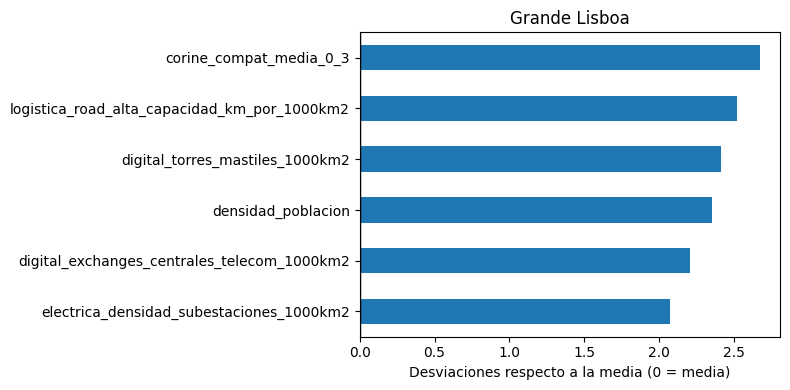

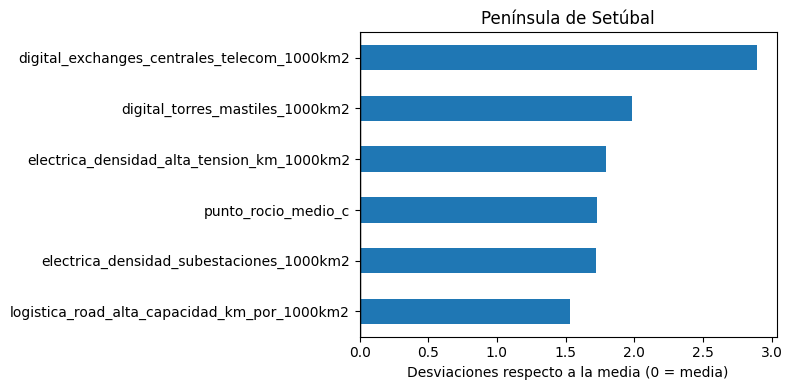

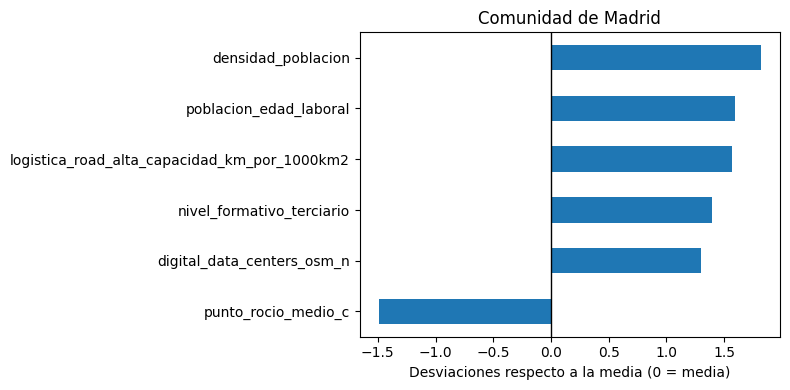

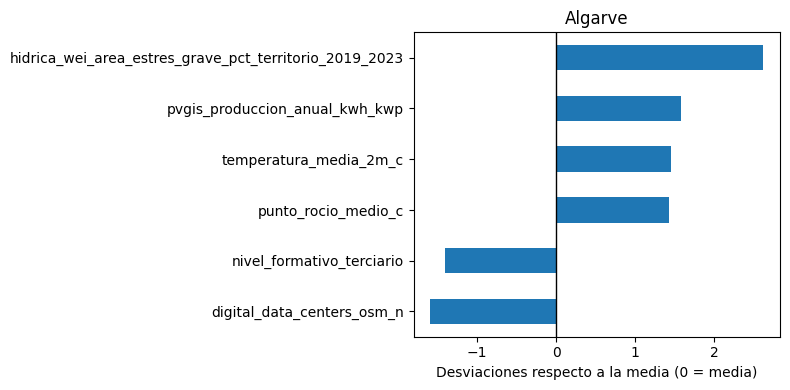

Perfiles: 4 | Registros: 24


,codigo_geo,nombre_territorio,variable,z_score,abs_z_score,ranking_variable
0,PT1A,Grande Lisboa,corine_compat_media_0_3,2.671268,2.671268,1
1,PT1A,Grande Lisboa,logistica_road_alta_capacidad_km_por_1000km2,2.516886,2.516886,2
2,PT1A,Grande Lisboa,digital_torres_mastiles_1000km2,2.408055,2.408055,3
3,PT1A,Grande Lisboa,densidad_poblacion,2.350379,2.350379,4
4,PT1A,Grande Lisboa,digital_exchanges_centrales_telecom_1000km2,2.206587,2.206587,5
5,PT1A,Grande Lisboa,electrica_densidad_subestaciones_1000km2,2.074180,2.074180,6
6,PT1B,Península de Setúbal,digital_exchanges_centrales_telecom_1000km2,2.892884,2.892884,1
7,PT1B,Península de Setúbal,digital_torres_mastiles_1000km2,1.987127,1.987127,2
8,PT1B,Península de Setúbal,electrica_densidad_alta_tension_km_1000km2,1.791788,1.791788,3
9,PT1B,Península de Setúbal,punto_rocio_medio_c,1.731061,1.731061,4


In [9]:
# Perfiles territoriales
registros_perfiles = []

for territorio in territorios_clave:
    fila_territorio = df.loc[
        df["nombre_territorio"] == territorio
    ].iloc[0]

    codigo = fila_territorio["codigo_geo"]
    fila = fila_territorio[variables].astype(float)

    extremos = fila.loc[
        fila.abs().nlargest(6).index
    ]

    for posicion, (variable, valor) in enumerate(
        extremos.items(),
        start=1,
    ):
        registros_perfiles.append({
            "codigo_geo": codigo,
            "nombre_territorio": territorio,
            "variable": variable,
            "z_score": valor,
            "abs_z_score": abs(valor),
            "ranking_variable": posicion,
        })

    extremos.sort_values().plot.barh(
        figsize=(8, 4),
        title=territorio,
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("Desviaciones respecto a la media (0 = media)")
    plt.ylabel("")
    plt.tight_layout()

    nombre_figura = f"perfil_{codigo.lower()}.png"
    plt.savefig(
        OUTPUT_DIR / nombre_figura,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

perfiles_territorios = pd.DataFrame(registros_perfiles)

print(
    "Perfiles:", len(territorios_clave),
    "| Registros:", len(perfiles_territorios),
)

display(perfiles_territorios.head(12))

## Síntesis de los resultados

Reunimos los resultados del modelo de referencia, las cinco semillas y los tres valores de `contamination`.

Para cada territorio mostramos su puntuación de anomalía, su posición en el ranking y cuántas veces fue identificado como singular en las pruebas realizadas.

Estas medidas se utilizan conjuntamente para valorar la consistencia de cada resultado. No creamos nuevas etiquetas ni eliminamos territorios automáticamente.

In [10]:
# Síntesis final de resultados
columnas_robustez = [
    "codigo_geo",
    "veces_singular",
    "frecuencia",
    "cont_05",
    "cont_10",
    "cont_15",
    "n_umbrales",
]
resumen_final = resultados_if.merge(
    resumen_robustez[columnas_robustez],
    on="codigo_geo",
    validate="one_to_one",
)
resumen_final = resumen_final.sort_values(
    "score_anomalia",
    ascending=False,
).reset_index(drop=True)
resumen_final.insert(
    0,
    "ranking_singularidad",
    np.arange(1, len(resumen_final) + 1),
)
if len(resumen_final) != 22:
    raise ValueError("La síntesis final necesita revisión.")

print("Territorios resumidos:", len(resumen_final))

display(resumen_final.head(10))

Territorios resumidos: 22


,ranking_singularidad,codigo_geo,nombre_territorio,pais,score_anomalia,singular,veces_singular,frecuencia,cont_05,cont_10,cont_15,n_umbrales
0,1,PT1A,Grande Lisboa,Portugal,0.040798,True,5,1.0,True,True,True,3
1,2,PT1B,Península de Setúbal,Portugal,0.001776,True,4,0.8,True,True,True,3
2,3,ES30,Comunidad de Madrid,España,0.000113,True,3,0.6,False,True,True,2
3,4,PT15,Algarve,Portugal,-0.001020,False,3,0.6,False,False,True,1
4,5,PT1C,Alentejo,Portugal,-0.003162,False,0,0.0,False,False,False,0
5,6,ES43,Extremadura,España,-0.003279,False,0,0.0,False,False,False,0
6,7,ES61,Andalucía,España,-0.011019,False,0,0.0,False,False,False,0
7,8,ES42,Castilla-La Mancha,España,-0.025698,False,0,0.0,False,False,False,0
8,9,PT11,Norte,Portugal,-0.026472,False,0,0.0,False,False,False,0
9,10,ES62,Región de Murcia,España,-0.026947,False,0,0.0,False,False,False,0


### Ranking de singularidad

Ordenamos los 22 territorios según la puntuación del modelo de referencia.

En este gráfico, **0 es el límite de Isolation Forest**, no la media:

- puntuación positiva: territorio singular;
- puntuación negativa: territorio no singular;
- cuanto más negativa sea la puntuación, mayor es su compatibilidad con el patrón general.

El ranking es descriptivo y no implica eliminar territorios.

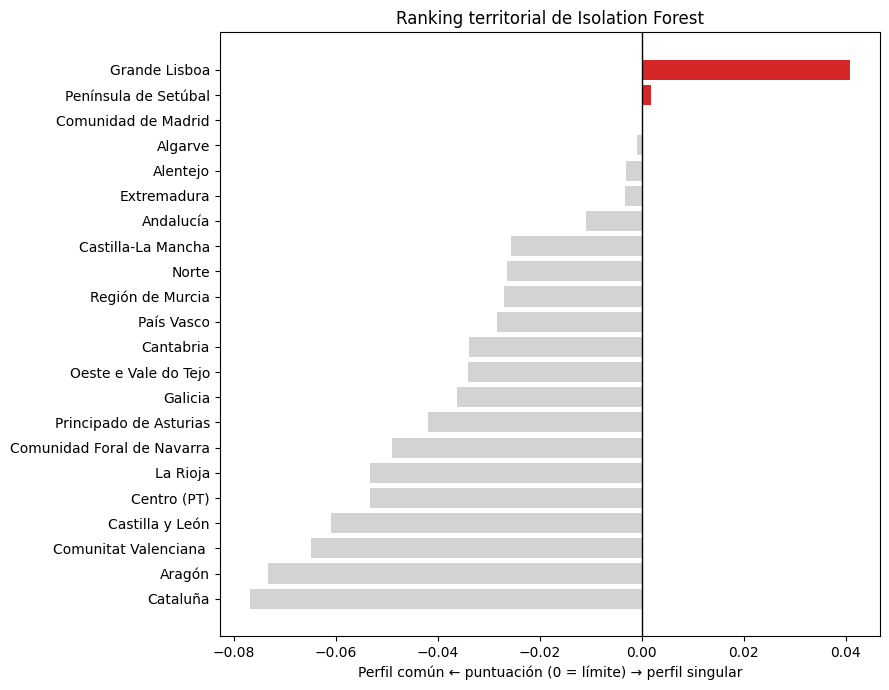

In [11]:
# Ranking de singularidad
ranking_grafico = resultados_if.sort_values(
    "score_anomalia"
)
colores = np.where(
    ranking_grafico["singular"],
    "tab:red",
    "lightgray",
)
fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    ranking_grafico["nombre_territorio"],
    ranking_grafico["score_anomalia"],
    color=colores,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Ranking territorial de Isolation Forest")
ax.set_xlabel(
    "Perfil común ← puntuación (0 = límite) → perfil singular"
)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "ranking_isolation_forest.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close()


### Interpretación de los resultados

El modelo de referencia, con `contamination=0.10`, identifica tres territorios singulares: Grande Lisboa, Península de Setúbal y Comunidad de Madrid.

Grande Lisboa presenta el resultado más consistente, ya que aparece en las cinco semillas y en los tres valores de `contamination`. Península de Setúbal también muestra una singularidad elevada, al aparecer en cuatro semillas y en los tres umbrales.

Comunidad de Madrid presenta una singularidad intermedia: aparece en tres semillas y con `contamination` de 0,10 y 0,15. Algarve es el caso menos estable, porque aparece en tres semillas, pero solamente con `contamination=0.15`.

Los perfiles muestran que:

- **Grande Lisboa** destaca principalmente por indicadores territoriales, logísticos, digitales y eléctricos.
- **Península de Setúbal** presenta valores elevados en infraestructura digital, eléctrica y viaria.
- **Comunidad de Madrid** destaca por densidad de población, población en edad laboral, accesibilidad viaria, formación y centros de datos.
- **Algarve** se diferencia sobre todo por el estrés hídrico, el potencial fotovoltaico y las condiciones climáticas.

Cataluña aparece al final del ranking porque su puntuación es la más negativa. Esto no significa que sea un territorio extremo, sino que su perfil es el más compatible con el patrón general según el modelo de referencia.

Las singularidades detectadas no representan necesariamente errores ni valoraciones negativas. Son territorios cuyo perfil conjunto se diferencia del resto, por lo que se mantienen todos los casos para los análisis posteriores.

## Exportación de los resultados

Guardamos las tablas principales, los perfiles territoriales y la configuración de Isolation Forest.

Estas salidas permiten conservar la trazabilidad del Notebook 13 y reutilizar los resultados en los análisis posteriores.

In [12]:
# Exportación de resultados
tablas_10a = {
    "resultado_isolation_forest_base.csv": resultados_if,
    "estabilidad_semillas.csv": estabilidad,
    "sensibilidad_contamination.csv": sensibilidad,
    "resumen_final_isolation_forest.csv": resumen_final,
    "perfiles_territorios_clave.csv": perfiles_territorios,
}

for nombre, tabla in tablas_10a.items():
    tabla.to_csv(
        OUTPUT_DIR / nombre,
        index=False,
    )

configuracion_if = {
    "territorios": len(X),
    "variables": variables,
    "n_variables": len(variables),
    "n_estimators": N_ESTIMATORS,
    "random_state": RANDOM_STATE,
    "contamination_base": CONTAMINATION_BASE,
    "semillas": semillas,
    "contaminaciones": contaminaciones,
    "archivo_entrada": MATRIZ_PATH.name,
}

ruta_configuracion = (
    OUTPUT_DIR / "configuracion_isolation_forest.json"
)
ruta_configuracion.write_text(
    json.dumps(
        configuracion_if,
        ensure_ascii=False,
        indent=4,
    ),
    encoding="utf-8",
)

codigos_clave = df.loc[
    df["nombre_territorio"].isin(territorios_clave),
    "codigo_geo",
].tolist()

figuras_esperadas = {
    "ranking_isolation_forest.png",
    *{
        f"perfil_{codigo.lower()}.png"
        for codigo in codigos_clave
    },
}

archivos_esperados = (
    set(tablas_10a)
    | figuras_esperadas
    | {"configuracion_isolation_forest.json"}
)

# Eliminamos únicamente restos de ejecuciones anteriores
# dentro de la carpeta exclusiva del Notebook 13.
for ruta in OUTPUT_DIR.iterdir():
    if ruta.is_file() and ruta.name not in archivos_esperados:
        ruta.unlink()

faltantes = [
    nombre
    for nombre in archivos_esperados
    if not (OUTPUT_DIR / nombre).exists()
]

if faltantes:
    raise FileNotFoundError(
        f"Faltan salidas esperadas: {faltantes}"
    )

print(
    "Tablas:", len(tablas_10a),
    "| Figuras:", len(figuras_esperadas),
    "| Configuración: 1",
)


Tablas: 5 | Figuras: 5 | Configuración: 1


## Conclusiones metodológicas

En este notebook hemos aplicado Isolation Forest sobre la matriz estandarizada del Notebook 12, formada por 22 territorios y 21 variables analíticas. No hemos seleccionado variables, aplicado transformaciones ni ajustado un nuevo escalador.

Con `contamination=0.10`, el modelo de referencia identifica como singulares a Grande Lisboa, Península de Setúbal y Comunidad de Madrid.

La comparación entre cinco semillas y tres valores de `contamination` muestra distintos niveles de consistencia:

- **Grande Lisboa** es el caso más estable: aparece con las cinco semillas y los tres umbrales.
- **Península de Setúbal** aparece con cuatro semillas y los tres umbrales.
- **Comunidad de Madrid** aparece con tres semillas y dos umbrales.
- **Algarve** aparece con tres semillas, pero únicamente con `contamination=0.15`.

Los perfiles territoriales indican que Grande Lisboa y Península de Setúbal destacan principalmente por indicadores logísticos, digitales y eléctricos. Comunidad de Madrid presenta un perfil metropolitano y socioeconómico diferenciado, mientras que Algarve sobresale por factores hídricos, climáticos y fotovoltaicos.

Estas variables sirven para describir los territorios, pero no representan una medida causal de importancia dentro de Isolation Forest.

No eliminamos ningún territorio. Conservamos las singularidades como información complementaria para comprobar posteriormente su relación con los resultados del PCA y del clustering.

## Paquete final

Agrupamos las 11 salidas del Notebook 13 en un archivo ZIP y comprobamos la integridad de sus archivos.


In [13]:
# ZIP final
import zipfile

archivos_12a = [
    ruta
    for ruta in OUTPUT_DIR.iterdir()
    if ruta.is_file()
]
if len(archivos_12a) != 11:
    raise ValueError("Faltan archivos para crear el ZIP.")
ZIP_PATH = Path(
    "/kaggle/working/"
    "NOTEBOOK_13_ISOLATION_FOREST_SALIDAS.zip"
)
with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED,
) as archivo_zip:
    for ruta in archivos_12a:
        archivo_zip.write(ruta, ruta.name)
with zipfile.ZipFile(ZIP_PATH) as archivo_zip:
    if archivo_zip.testzip() is not None:
        raise ValueError("El ZIP contiene errores.")

print("Archivos ZIP:", len(archivos_12a))
print("ZIP:", ZIP_PATH)

Archivos ZIP: 11
ZIP: /kaggle/working/NOTEBOOK_13_ISOLATION_FOREST_SALIDAS.zip
